# Stage 1 Labeling Artifact Analysis

This notebook inspects the processed OHLCV datasets and label reports generated by the Stage 1 pipeline.


In [18]:
! pip install pandas pyarrow matplotlib seaborn

In [19]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_PLOTTING = True
    
except ImportError:
    HAS_PLOTTING = False
    plt = None
    sns = None
    print('Install matplotlib and seaborn to enable visualizations.')


In [28]:
DATA_ROOT = Path('../data')
DATASETS_DIR = DATA_ROOT / 'datasets'
REPORTS_DIR = DATA_ROOT / 'reports'
PROCESSED_DIR = DATA_ROOT / 'processed'

dataset_paths = sorted(DATASETS_DIR.glob('*.parquet'))
report_paths = sorted(REPORTS_DIR.glob('*.json'))
processed_paths = sorted(PROCESSED_DIR.glob('*.parquet'))

print(f'Total datasets: {len(dataset_paths)}')
print(f'Total reports:  {len(report_paths)}')
print(f'Total processed files: {len(processed_paths)}')

if dataset_paths:
    print('First dataset file:', dataset_paths[0].name)
if report_paths:
    print('First report file:', report_paths[0].name)


Total datasets: 25
Total reports:  25
Total processed files: 1
First dataset file: BTCUSDT_4h_backW1_forW1.parquet
First report file: BTCUSDT_4h_backW1_forW1.json


In [22]:
def load_reports(paths) -> pd.DataFrame:
    records = []
    for path in paths:
        with path.open('r', encoding='utf-8') as handle:
            payload: Dict[str, Any] = json.load(handle)
        record: Dict[str, Any] = {
            'symbol': payload['symbol'],
            'interval': payload['interval'],
            'backW': payload['backW'],
            'forW': payload['forW'],
            'alpha': payload['alpha'],
            'beta': payload['beta'],
            'fee': payload['fee'],
            'dataset_path': payload['dataset_path'],
            'n_valid': payload['n_valid'],
            'n_total': payload['n_total'],
        }
        counts = payload.get('counts', {})
        for label, value in counts.items():
            record[f'count_{label.lower()}'] = value
        distribution = payload.get('distribution', {})
        for label, value in distribution.items():
            record[f'dist_{label.lower()}'] = value
        records.append(record)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame.from_records(records)
    df = df.sort_values(['forW', 'backW']).reset_index(drop=True)
    return df

report_df = load_reports(report_paths)
report_df.head()


,symbol,interval,backW,forW,alpha,beta,fee,dataset_path,n_valid,n_total,count_buy,count_hold,count_sell,count_nan,dist_buy,dist_hold,dist_sell
0,BTCUSDT,4h,1,1,0.004826,0.065218,0.002,data/datasets/BTCUSDT_4h_backW1_forW1.parquet,17818,17818,4891,6606,6321,0,0.274498,0.370749,0.354754
1,BTCUSDT,4h,2,1,0.004826,0.065218,0.002,data/datasets/BTCUSDT_4h_backW2_forW1.parquet,17817,17817,4890,6606,6321,0,0.274457,0.370769,0.354774
2,BTCUSDT,4h,3,1,0.004826,0.065218,0.002,data/datasets/BTCUSDT_4h_backW3_forW1.parquet,17816,17816,4890,6605,6321,0,0.274472,0.370734,0.354793
3,BTCUSDT,4h,4,1,0.004826,0.065218,0.002,data/datasets/BTCUSDT_4h_backW4_forW1.parquet,17815,17815,4890,6605,6320,0,0.274488,0.370755,0.354757
4,BTCUSDT,4h,5,1,0.004826,0.065218,0.002,data/datasets/BTCUSDT_4h_backW5_forW1.parquet,17814,17814,4890,6605,6319,0,0.274503,0.370776,0.354721


## Label Distribution Overview

The next cell visualises how the BUY/HOLD/SELL share changes across forward windows.


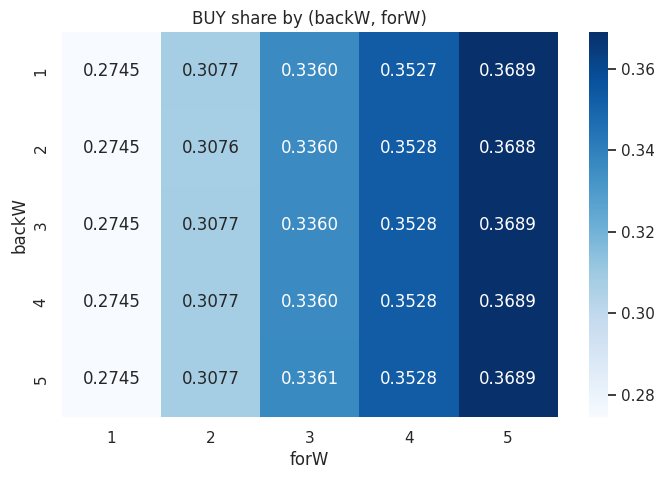

In [32]:
if HAS_PLOTTING and not report_df.empty:
    pivot_buy = report_df.pivot(index='backW', columns='forW', values='dist_buy')
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_buy, annot=True, fmt='.4f', cmap='Blues')
    plt.title('BUY share by (backW, forW)')
    plt.ylabel('backW')
    plt.xlabel('forW')
    plt.show()

else:
    print('Report data unavailable or plotting libraries missing.')


Symbols:   ['BTCUSDT']
Intervals: ['4h']
Grid size: backW=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], forW=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,forW,backW,coverage,dist_hold,dist_buy,dist_sell,alpha,beta,n_valid
0,1,1,1.0,0.370749,0.274498,0.354754,0.004826,0.065218,17818
1,1,2,1.0,0.370769,0.274457,0.354774,0.004826,0.065218,17817
2,1,3,1.0,0.370734,0.274472,0.354793,0.004826,0.065218,17816
3,1,4,1.0,0.370755,0.274488,0.354757,0.004826,0.065218,17815
4,1,5,1.0,0.370776,0.274503,0.354721,0.004826,0.065218,17814
5,2,1,1.0,0.316103,0.307684,0.376214,0.004826,0.071740,17817
6,2,2,1.0,0.316120,0.307645,0.376235,0.004826,0.071740,17816
7,2,3,1.0,0.316082,0.307662,0.376256,0.004826,0.071740,17815
8,2,4,1.0,0.316100,0.307679,0.376221,0.004826,0.071740,17814
9,2,5,1.0,0.316117,0.307697,0.376186,0.004826,0.071740,17813


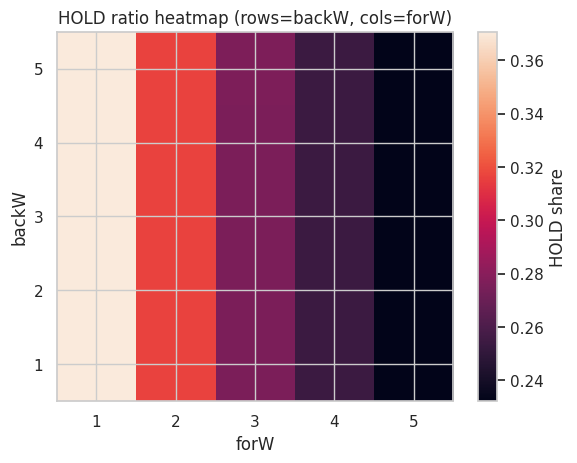

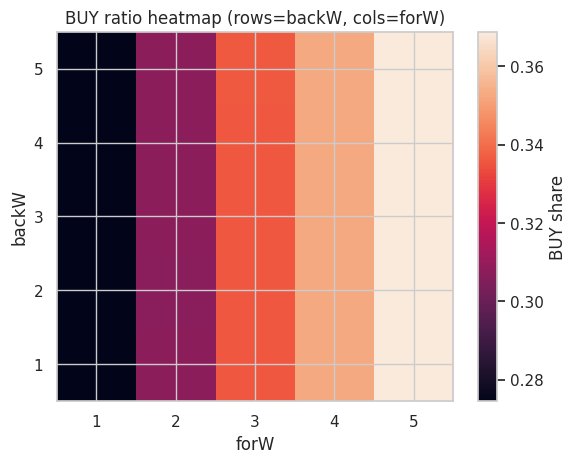

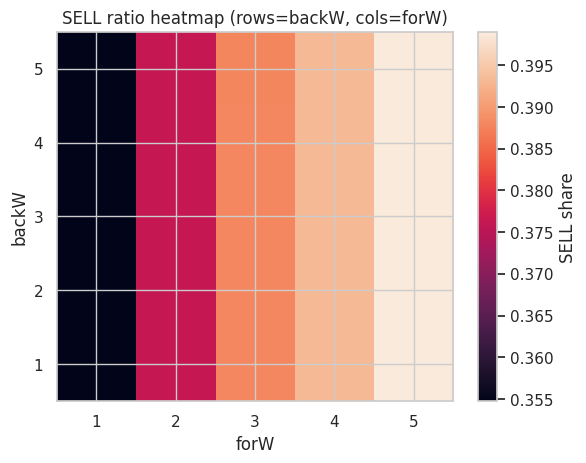


Top 10 (backW, forW) by class-balance score:


,backW,forW,dist_hold,dist_buy,dist_sell,n_valid,alpha,beta,dataset_path,score
0,5,1,0.370776,0.274503,0.354721,17814,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW5_forW1.parquet,0.061664
1,2,1,0.370769,0.274457,0.354774,17817,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW2_forW1.parquet,0.061677
2,4,1,0.370755,0.274488,0.354757,17815,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW4_forW1.parquet,0.061687
3,1,1,0.370749,0.274498,0.354754,17818,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW1_forW1.parquet,0.061691
4,3,1,0.370734,0.274472,0.354793,17816,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW3_forW1.parquet,0.061710
5,5,2,0.316117,0.307697,0.376186,17813,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW5_forW2.parquet,0.120690
6,2,2,0.316120,0.307645,0.376235,17816,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW2_forW2.parquet,0.120693
7,1,2,0.316103,0.307684,0.376214,17817,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW1_forW2.parquet,0.120712
8,4,2,0.316100,0.307679,0.376221,17814,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW4_forW2.parquet,0.120717
9,3,2,0.316082,0.307662,0.376256,17815,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW3_forW2.parquet,0.120743



Top-3 per forW:


,forW,backW,dist_hold,dist_buy,dist_sell,n_valid,alpha,beta,dataset_path,score
0,1,5,0.370776,0.274503,0.354721,17814,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW5_forW1.parquet,0.061664
1,1,2,0.370769,0.274457,0.354774,17817,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW2_forW1.parquet,0.061677
2,1,4,0.370755,0.274488,0.354757,17815,0.004826,0.065218,data/datasets/BTCUSDT_4h_backW4_forW1.parquet,0.061687
5,2,5,0.316117,0.307697,0.376186,17813,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW5_forW2.parquet,0.120690
6,2,2,0.316120,0.307645,0.376235,17816,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW2_forW2.parquet,0.120693
7,2,1,0.316103,0.307684,0.376214,17817,0.004826,0.071740,data/datasets/BTCUSDT_4h_backW1_forW2.parquet,0.120712
10,3,5,0.275994,0.336066,0.387941,17812,0.004826,0.078261,data/datasets/BTCUSDT_4h_backW5_forW3.parquet,0.176971
11,3,4,0.275978,0.336047,0.387975,17813,0.004826,0.078261,data/datasets/BTCUSDT_4h_backW4_forW3.parquet,0.176998
12,3,3,0.275963,0.336028,0.388009,17814,0.004826,0.078261,data/datasets/BTCUSDT_4h_backW3_forW3.parquet,0.177025
15,4,1,0.254056,0.352736,0.393208,17815,0.004826,0.084783,data/datasets/BTCUSDT_4h_backW1_forW4.parquet,0.212529



β consistency per forW (should be constant across backW in exact_paper):


,min,max,std_beta
forW,,,
1,0.065218,0.065218,0.0
2,0.071740,0.071740,0.0
3,0.078261,0.078261,0.0
4,0.084783,0.084783,0.0
5,0.091305,0.091305,0.0


α consistency per forW (should be constant/global):


,min,max,std_alpha
forW,,,
1,0.004826,0.004826,0.0
2,0.004826,0.004826,0.0
3,0.004826,0.004826,0.0
4,0.004826,0.004826,0.0
5,0.004826,0.004826,0.0


Mode guess: exact_paper (β constant per forW, α constant globally).

Recommendations:
 - backW=5, forW=1 | H=37.1%, B=27.5%, S=35.5% | alpha=0.00483, beta=0.06522 | n=17814
 - backW=2, forW=1 | H=37.1%, B=27.4%, S=35.5% | alpha=0.00483, beta=0.06522 | n=17817
 - backW=4, forW=1 | H=37.1%, B=27.4%, S=35.5% | alpha=0.00483, beta=0.06522 | n=17815
 - backW=1, forW=1 | H=37.1%, B=27.4%, S=35.5% | alpha=0.00483, beta=0.06522 | n=17818
 - backW=3, forW=1 | H=37.1%, B=27.4%, S=35.5% | alpha=0.00483, beta=0.06522 | n=17816


In [33]:
# =========================
# Stage 1 - data/ analysis
# (paste below your `report_df = load_reports(report_paths)`)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

if report_df.empty:
    print("No reports found. Make sure data/reports/*.json exist.")
else:
    # --- Normalize column names (if needed) ---
    # Expecting: dist_buy, dist_sell, dist_hold, alpha, beta, backW, forW, n_valid, n_total
    needed = {"dist_buy","dist_sell","dist_hold","alpha","beta","backW","forW","n_valid","n_total"}
    missing = [c for c in needed if c not in report_df.columns]
    if missing:
        raise ValueError(f"Missing columns in reports: {missing}")

    # --- Quick overview ---
    print(f"Symbols:   {sorted(report_df['symbol'].unique())}")
    print(f"Intervals: {sorted(report_df['interval'].unique())}")
    print(f"Grid size: backW={sorted(report_df['backW'].unique())}, forW={sorted(report_df['forW'].unique())}")

    # Coverage and class balance
    report_df["coverage"] = report_df["n_valid"] / report_df["n_total"].replace(0, np.nan)
    overview = report_df[["forW","backW","coverage","dist_hold","dist_buy","dist_sell","alpha","beta","n_valid"]].copy()
    display(overview.head(10))

    # --- Build matrices for heatmaps (rows=backW, cols=forW) ---
    bw = sorted(report_df["backW"].unique())
    fw = sorted(report_df["forW"].unique())

    def to_matrix(metric: str) -> np.ndarray:
        M = np.full((len(bw), len(fw)), np.nan)
        for i, b in enumerate(bw):
            for j, f in enumerate(fw):
                row = report_df[(report_df.backW==b) & (report_df.forW==f)]
                if len(row) == 1:
                    M[i, j] = float(row.iloc[0][metric])
        return M

    H = to_matrix("dist_hold")
    B = to_matrix("dist_buy")
    S = to_matrix("dist_sell")

    # --- Heatmaps ---
    def heatmap(M, title, cbar_label):
        plt.figure()
        plt.imshow(M, aspect='auto', origin='lower')
        plt.title(title)
        plt.xlabel("forW")
        plt.ylabel("backW")
        plt.xticks(range(len(fw)), fw)
        plt.yticks(range(len(bw)), bw)
        plt.colorbar(label=cbar_label)
        plt.show()

    heatmap(H, "HOLD ratio heatmap (rows=backW, cols=forW)", "HOLD share")
    heatmap(B, "BUY ratio heatmap (rows=backW, cols=forW)", "BUY share")
    heatmap(S, "SELL ratio heatmap (rows=backW, cols=forW)", "SELL share")

    # --- Candidate ranking (simple balance score) ---
    def band_penalty(x, lo, hi):
        if x < lo: return (lo - x)**2
        if x > hi: return (x - hi)**2
        return 0.0

    def score_row(row):
        # Target bands: HOLD in [0.50, 0.80]; BUY & SELL in [0.10, 0.25]
        p = 0.0
        p += band_penalty(row["dist_hold"], 0.50, 0.80) * 3.0
        p += band_penalty(row["dist_buy"],  0.10, 0.25) * 1.0
        p += band_penalty(row["dist_sell"], 0.10, 0.25) * 1.0
        # Light penalty for very small sample size
        if row["n_valid"] < 500:
            p += 0.5
        return p

    cand = report_df.copy()
    cand["score"] = cand.apply(score_row, axis=1)
    cand = cand.sort_values(["score","forW","backW","beta"]).reset_index(False)

    print("\nTop 10 (backW, forW) by class-balance score:")
    display(cand[["backW","forW","dist_hold","dist_buy","dist_sell","n_valid","alpha","beta","dataset_path","score"]].head(10))

    # --- Per-forW best combos (top 3 each) ---
    tops_per_forw = (
        cand.sort_values(["forW","score","backW"])
            .groupby("forW")
            .head(3)[["forW","backW","dist_hold","dist_buy","dist_sell","n_valid","alpha","beta","dataset_path","score"]]
    )
    print("\nTop-3 per forW:")
    display(tops_per_forw)

    # --- Consistency checks for exact_paper mode ---
    beta_spread = cand.groupby("forW")["beta"].agg(["min","max","std"]).rename(columns={"std":"std_beta"})
    alpha_spread = cand.groupby("forW")["alpha"].agg(["min","max","std"]).rename(columns={"std":"std_alpha"})
    print("\nβ consistency per forW (should be constant across backW in exact_paper):")
    display(beta_spread)
    print("α consistency per forW (should be constant/global):")
    display(alpha_spread)

    # Heuristics to guess mode:
    if (beta_spread["std_beta"] < 1e-12).all() and (alpha_spread["std_alpha"] < 1e-12).all():
        print("Mode guess: exact_paper (β constant per forW, α constant globally).")
    else:
        print("Mode guess: per_forw_percentile or mixed (β/α vary across backW).")

    # --- Quick text recommendations ---
    def fmt_pct(x): 
        return f"{x*100:.1f}%"

    print("\nRecommendations:")
    for _, r in cand.head(5).iterrows():
        print(
            f" - backW={int(r.backW)}, forW={int(r.forW)} | "
            f"H={fmt_pct(r.dist_hold)}, B={fmt_pct(r.dist_buy)}, S={fmt_pct(r.dist_sell)} | "
            f"alpha={r.alpha:.5f}, beta={r.beta:.5f} | n={int(r.n_valid)}"
        )

    # Optional: save candidates table to CSV (uncomment if you want a file)
    # out_csv = REPORTS_DIR / "candidates_ranked.csv"
    # cand.to_csv(out_csv, index=False)
    # print(f"Saved ranked candidates to: {out_csv}")